## Exploring the dataset and what project is about

In [2]:
from pathlib import Path
NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parent
SEG_DATASET_DIR = BASE_DIR / "data" / "kvasir-seg" / "Kvasir-SEG"
INPUT_DIR = SEG_DATASET_DIR / "images"
TARGET_DIR = SEG_DATASET_DIR / "masks"
ANNOTATION_FILE = SEG_DATASET_DIR / "kavsir_bboxes.json"

In [20]:
import json
from collections import Counter
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [ ]:
# Read and parse the JSON file
with open(ANNOTATION_FILE, "r") as f:
    data = json.load(f)  
# Initialize Counter
label_counter = Counter()
# Count all labels
for value in data.values():
    for box in value.get("bbox", []):
        label = box.get("label")
        if label:
            label_counter[label] += 1

# Results
print("Number of dictionaries:", len(data))
print("Unique labels:", list(label_counter.keys()))
print("Label counts:", dict(label_counter))


Number of dictionaries: 1000
Unique labels: ['polyp']
Label counts: {'polyp': 1071}


In [16]:
folder = INPUT_DIR
size_counter = Counter()
# Loop through all image files in the folder (non-recursive)
for file in folder.iterdir():
    if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tiff"]:
        try:
            with Image.open(file) as img:
                size = img.size  # (width, height)
                size_counter[size] += 1
        except Exception as e:
            print(f"Could not open {file.name}: {e}")
# Print results
print("Unique image sizes and their counts:")
print("Total unique sizes:", len(size_counter))
for (w, h), count in size_counter.items():
    print(f"Size {w}x{h}       → {count} images")

Unique image sizes and their counts:
Total unique sizes: 333
Size 622x529       → 56 images
Size 1348x1070       → 17 images
Size 619x529       → 4 images
Size 622x528       → 53 images
Size 617x528       → 3 images
Size 626x547       → 66 images
Size 621x530       → 11 images
Size 1214x1019       → 1 images
Size 570x531       → 19 images
Size 622x530       → 78 images
Size 611x530       → 3 images
Size 626x546       → 61 images
Size 622x531       → 50 images
Size 623x529       → 8 images
Size 609x546       → 1 images
Size 620x547       → 1 images
Size 594x528       → 2 images
Size 624x546       → 1 images
Size 607x530       → 2 images
Size 616x528       → 6 images
Size 571x530       → 14 images
Size 481x530       → 1 images
Size 560x529       → 1 images
Size 616x530       → 7 images
Size 621x528       → 10 images
Size 605x510       → 1 images
Size 623x528       → 14 images
Size 519x511       → 1 images
Size 459x526       → 1 images
Size 600x529       → 2 images
Size 622x511       → 2 

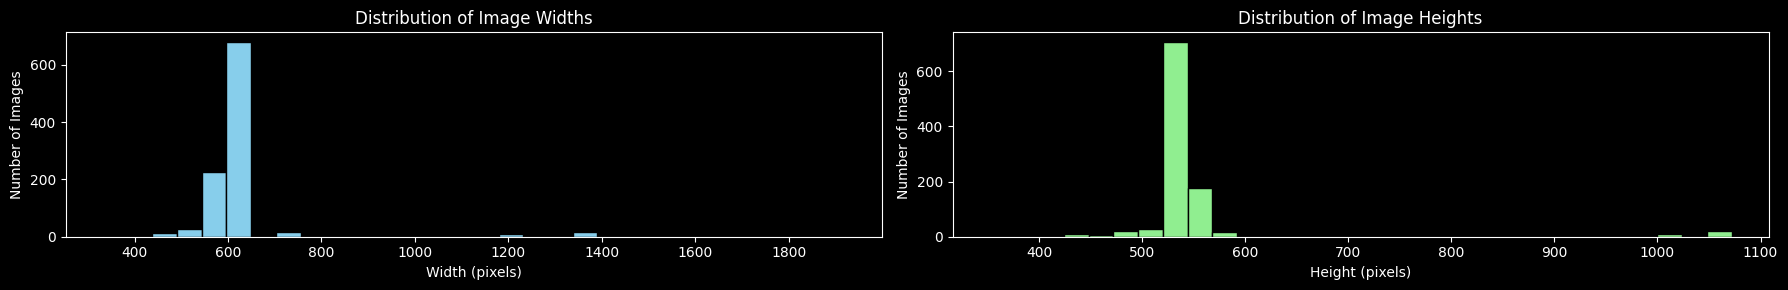

: 

In [ ]:

# Extract widths, heights, and their counts
widths = [w for (w, h) in size_counter.keys() for _ in range(size_counter[(w, h)])]
heights = [h for (w, h) in size_counter.keys() for _ in range(size_counter[(w, h)])]

# Create two subplots
plt.figure(figsize=(18, 3))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()
